In [1]:
import pandas as pd
import os
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from util import calculate_pass_at_k

In [3]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [4]:

def question_from_prompt(x : list[dict]):
    inp = x[1]['content']
    qindex, sindex = inp.rindex('\n\n\nQuestion'), inp.rindex("\n\nStudent's correct answer:")
    return inp[qindex : sindex]

def solution_from_prompt(x : list[dict]):
    inp = x[1]['content']
    sindex, instr_index = inp.rindex("\n\nStudent's correct answer:"), inp.rindex('\n\nPlease only answer either')
    return inp[sindex: instr_index].removeprefix("\n\nStudent's correct answer:\n\n")

def parse(response : list[str]):
    r = response[0]
    if len(r) <= 10: # deprecated answer
        return False
    tail = r[-10:]
    try:
        ans_index = tail.rindex('#### ')
    except:
        return False
    if 'Python' in response[0]:
        return False
    return 'yes' in tail[ans_index:]

def pass_at_k(rewards, k):
    """
    Compute pass@k for a list or array of binary rewards.
    Args:
        rewards (list or np.ndarray): Binary vector where 1 = success, 0 = failure.
        k (int): The number of samples considered for pass@k.
    Returns:
        float: Estimated pass@k value.
    """
    rewards = np.array(rewards)
    n = len(rewards)
    c = rewards.sum()
    if c == 0:
        return 0.0
    if n - c < k:
        return 1.0
    return 1.0 - np.prod([(n - c - i) / (n - i) for i in range(k)]) 


In [1]:
from typing import Callable

with open('/u/rfechner/data/verified_at_k/base_klcov_64samples_chats-out.parquet', 'rb') as file:
    df = pd.read_parquet(file)

colors = {
    'base' : 'black',
    'klcov' : 'green'
}
name_mapper = {
    'base' : 'Base',
    'klcov' : 'KL-Cov'
}

def plot_intersection(df):
    comparison_functions = [
        lambda arr : arr >= 0, # all questions
        lambda arr : arr >= 0.8, # questions with high pass@1
        lambda arr : arr <= 0.2, # questions with low pass@1
    ]
    handles = [
        'All data', 'Pass@1 $\\geq$ 0.8', 'Pass@1 $\\leq$ 0.2'
    ]
    # separate df into methods
    base, klcov = df[df['method'] == 'base'].copy(), df[df['method'] == 'klcov'].copy()
    base['input'] = base['prompt'].apply(question_from_prompt)
    klcov['input'] = klcov['prompt'].apply(question_from_prompt)

    # calculate pass@1 for each method
    passk_base, passk_klcov = calculate_pass_at_k(base, ks=2**np.arange(7)), calculate_pass_at_k(klcov, ks=2**np.arange(7))
    pass1_base, pass1_klcov = [], []
    for dataset_name in passk_base.keys():
        pass1_base.append(passk_base[dataset_name][:, 0])
        pass1_klcov.append(passk_klcov[dataset_name][:, 0])
    pass1_base, pass1_klcov = np.concat(pass1_base, axis=0), np.concat(pass1_klcov, axis=0)

    # plotting
    fig, axes = plt.subplots(nrows=1, ncols=len(handles), figsize=(3 * len(handles), 2))
    axes = axes.flatten()
    for ax, comparison_fn, handle in zip(axes, comparison_functions, handles):
        
        # build mask based on provided compairson function and apply the mask to get the intersection of interest
        mask = comparison_fn(pass1_base) & comparison_fn(pass1_klcov)
        dfmask = mask[:, None]
        dfmask = np.repeat(dfmask, repeats=64, axis=1)
        dfmask = dfmask.flatten()
        base_filt, klcov_filt = base[dfmask].copy(), klcov[dfmask].copy()
        df_filt = pd.concat([base_filt, klcov_filt], axis=0)

        # parse out whether the response contains a positive classification, build verify@k
        df_filt['verified'] = df_filt['responses'].apply(parse)
        plotting_values = {}
        for method, df_method in df_filt.groupby('method', sort=False):
            passks = []
            for q, df_method_input in df_method.groupby('input', sort=False):
                passks.append([pass_at_k(df_method_input['verified'].astype(int), k) for k in 2 ** np.arange(7)])
            plotting_values[method] = np.array(passks).mean(axis=0)

        
        for k, vs in plotting_values.items():
            ax.plot(vs, color=colors[k], label=name_mapper[k])
        ax.set_title(f'Verify@k   {handle}')
        ax.set_xticks(np.arange(len(vs)), 2**np.arange(len(vs)))
        ax.set_xlabel('k')
        ax.grid()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2, frameon=False,
        bbox_to_anchor=(0.5, -0.1),
    )
    fig.savefig(os.path.join('/u/rfechner/verl/plots/outcome_based2', 'verify_at_k_klcov'), format="pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()

NameError: name 'pd' is not defined

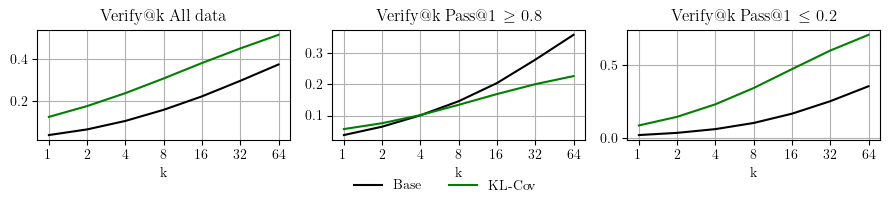

In [14]:
plot_intersection(df)

In [15]:
with open('/u/rfechner/data/verified_at_k/base_klcov_64samples_chats-out.parquet', 'rb') as file:
    df = pd.read_parquet(file)

df['input'] = df['prompt'].apply(question_from_prompt)
df['verified'] = df['responses'].apply(parse)


In [16]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B')

In [17]:
df['solution'] = df['prompt'].apply(solution_from_prompt)
df['response_tokens'] = df['solution'].apply(lambda x : len(tokenizer.encode(x)))

In [18]:
def calculate_metrics(df):
    # 1. Verification-Conditioned Accuracy
    # Wir schauen: Wenn verifiziert wurde, war die Antwort korrekt?
    v_true = df[df['verified'] == True]['reward'].mean()
    v_false = df[df['verified'] == False]['reward'].mean()
    delta = v_true - v_false
    
    # 2. Verification per 1000 Tokens
    # Annahme: Spalte 'response_tokens' (Anzahl der Tokens) ist vorhanden
    total_verifications = df['verified'].sum()
    total_tokens = df['response_tokens'].sum()
    v_per_1k = (total_verifications / total_tokens) * 1000 if total_tokens > 0 else 0
    
    return v_true, v_false, delta, v_per_1k

def plot_enhanced_analysis(df):
    
    methods = ['base', 'klcov']
    results = []

    # Filter-Logik via Groupby (Sicherer als Flatten-Masks)
    stats_per_input = df.groupby(['input', 'method'])['reward'].mean().unstack()
    
    filters = {
        'All data': stats_per_input.index,
        'Pass@1 >= 0.8': stats_per_input[(stats_per_input['base'] >= 0.8) & (stats_per_input['klcov'] >= 0.8)].index,
        'Pass@1 <= 0.2': stats_per_input[(stats_per_input['base'] <= 0.2) & (stats_per_input['klcov'] <= 0.2)].index
    }

    for name, valid_inputs in filters.items():
        subset = df[df['input'].isin(valid_inputs)]
        
        print(f"\n--- {name} ---")
        for m in methods:
            m_df = subset[subset['method'] == m]
            v_true, v_false, delta, v_1k = calculate_metrics(m_df)
            print(f"[{m}] Acc|V: {v_true:.2f}, Acc|!V: {v_false:.2f}, Delta: {delta:.2f}, V/1k: {v_1k:.2f}")

def plot_enhanced_analysis_to_latex(df):
    methods = ['base', 'klcov']
    stats_per_input = df.groupby(['input', 'method'])['reward'].mean().unstack()
    
    filters = {
        'All data': stats_per_input.index,
        'Pass@1 $\\geq$ 0.8': stats_per_input[(stats_per_input['base'] >= 0.8) & (stats_per_input['klcov'] >= 0.8)].index,
        'Pass@1 $\\leq$ 0.2': stats_per_input[(stats_per_input['base'] <= 0.2) & (stats_per_input['klcov'] <= 0.2)].index
    }

    # LaTeX Table Header
    print(r"\begin{table}[h]")
    print(r"\centering")
    print(r"\begin{tabular}{llcccc}")
    print(r"\toprule")
    print(r"Subset & Method & $Acc|V$ & $Acc|\neg V$ & $\Delta$ & $V/1k$ Tokens \\")
    print(r"\midrule")

    for name, valid_inputs in filters.items():
        subset = df[df['input'].isin(valid_inputs)]
        
        # Um "Multirow" Optik zu simulieren: Subset Name nur beim ersten Mal drucken
        first_row = True
        for m in methods:
            m_df = subset[subset['method'] == m]
            v_true, v_false, delta, v_1k = calculate_metrics(m_df)
            
            subset_label = name if first_row else ""
            method_label = "Base" if m == 'base' else "KL-Cov"
            
            print(f"{subset_label} & {method_label} & {v_true:.3f} & {v_false:.3f} & {delta:.3f} & {v_1k:.2f} \\\\")
            first_row = False
        print(r"\hline") # Trennung zwischen den Subsets

    # LaTeX Table Footer
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\caption{Verification-Conditioned Accuracy and Density for Base vs. KL-Cov (RLVR).}")
    print(r"\label{tab:verification_metrics}")
    print(r"\end{table}")

In [19]:
plot_enhanced_analysis(df)


--- All data ---
[base] Acc|V: 0.66, Acc|!V: 0.34, Delta: 0.31, V/1k: 0.06
[klcov] Acc|V: 0.72, Acc|!V: 0.62, Delta: 0.09, V/1k: 0.16

--- Pass@1 >= 0.8 ---
[base] Acc|V: 0.95, Acc|!V: 0.87, Delta: 0.08, V/1k: 0.10
[klcov] Acc|V: 0.99, Acc|!V: 1.00, Delta: -0.00, V/1k: 0.12

--- Pass@1 <= 0.2 ---
[base] Acc|V: 0.04, Acc|!V: 0.02, Delta: 0.02, V/1k: 0.02
[klcov] Acc|V: 0.02, Acc|!V: 0.02, Delta: -0.00, V/1k: 0.07


In [20]:
plot_enhanced_analysis_to_latex(df)

\begin{table}[h]
\centering
\begin{tabular}{llcccc}
\toprule
Subset & Method & $Acc|V$ & $Acc|\neg V$ & $\Delta$ & $V/1k$ Tokens \\
\midrule
All data & Base & 0.657 & 0.343 & 0.315 & 0.06 \\
 & KL-Cov & 0.716 & 0.621 & 0.095 & 0.16 \\
\hline
Pass@1 $\geq$ 0.8 & Base & 0.953 & 0.873 & 0.080 & 0.10 \\
 & KL-Cov & 0.995 & 0.997 & -0.002 & 0.12 \\
\hline
Pass@1 $\leq$ 0.2 & Base & 0.040 & 0.016 & 0.024 & 0.02 \\
 & KL-Cov & 0.020 & 0.023 & -0.003 & 0.07 \\
\hline
\bottomrule
\end{tabular}
\caption{Verification-Conditioned Accuracy and Density for Base vs. KL-Cov (RLVR).}
\label{tab:verification_metrics}
\end{table}
